In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [25]:
PATH = r"C:\Users\scjaa\AAC - CENTRO DE ACUSTICA APLICADA, S.L\I + D + i - Documentos\Modelos_IA\AAC_IA_Puerto\ETIQUETAS\SANTUR_2023_12"

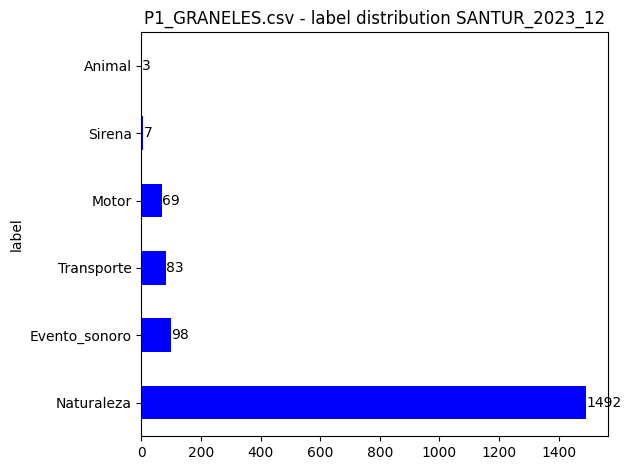

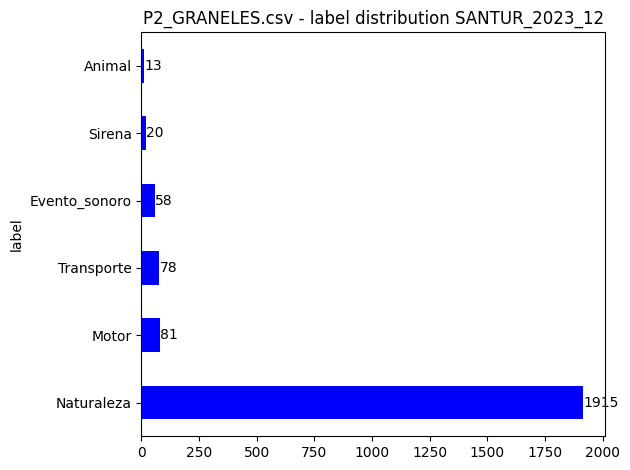

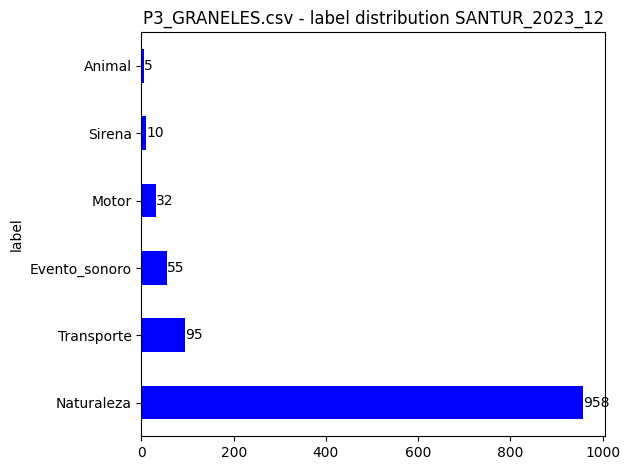

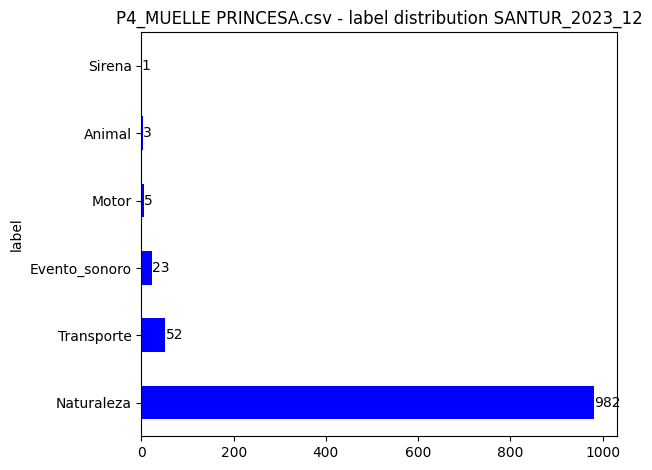

<Figure size 640x480 with 0 Axes>

In [38]:
files = os.listdir(PATH)
output_path = os.path.join(PATH, "plots")
os.makedirs(output_path, exist_ok=True)

title = PATH.split("\\")[-1]

all_labels = []

for file in files:
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(PATH, file))
        
        # Plot a horizontal histogram for the 'label' column
        value_counts = df['label'].value_counts()
        ax = value_counts.plot(kind='barh', color='blue')


        for i in ax.patches:
            ax.text(i.get_width() + 0.1, i.get_y() + i.get_height()/2, 
                    str(int(i.get_width())), 
                    ha='left', va='center')


        # remove grid
        plt.title(f'{file} - label distribution {title}')
        plt.tight_layout()
        plt.show()

        # save
        # plt.savefig(os.path.join(output_path, f'{file}_cound_label.png'))
        # clear the plot
        plt.clf()

Total number of audio files: 6144


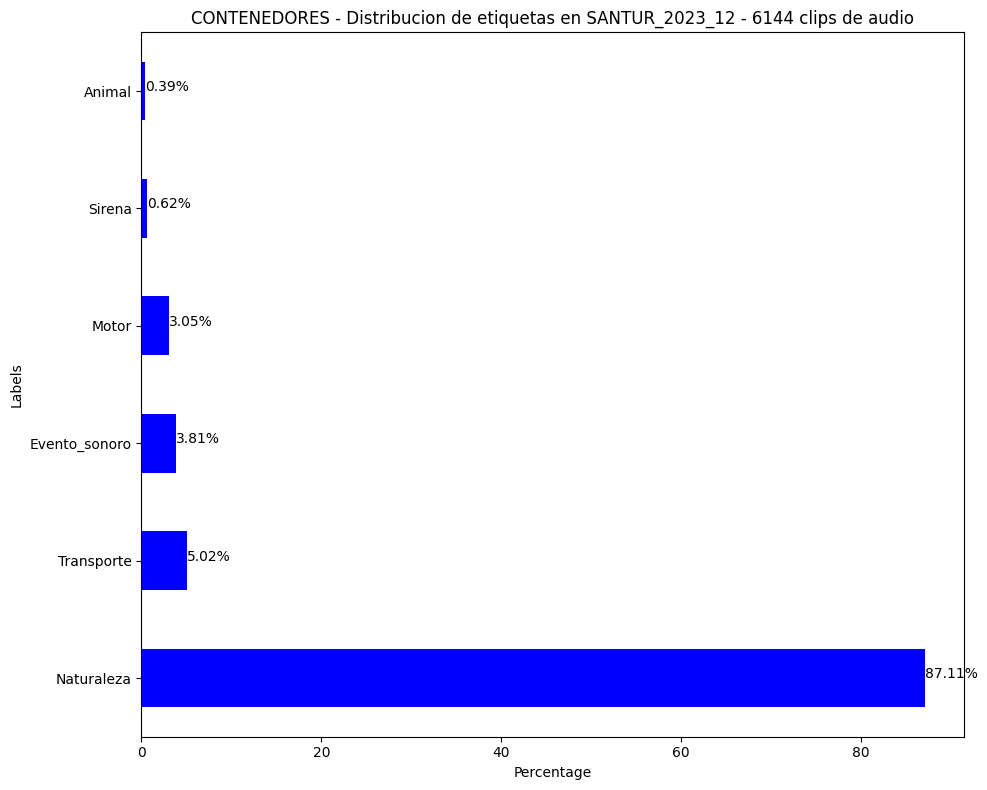

In [27]:
files = os.listdir(PATH)
all_labels = []
total_audio_files = 0

for file in files:
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(PATH, file))
        all_labels.extend(df['label'])
        total_audio_files += len(df)


label_data = pd.Series(all_labels)
# calculate value counts and convert to percentage
label_counts = label_data.value_counts(normalize=True) * 100

output_path = os.path.join(PATH, "plots")
os.makedirs(output_path, exist_ok=True)

# plot
plt.figure(figsize=(10, 8))
label_counts.plot(kind='barh', color='blue')
plt.title(f'CONTENEDORES - Distribucion de etiquetas en {title} - {total_audio_files} clips de audio')
plt.xlabel('Percentage')
plt.ylabel('Labels')

#annotate each bar with percentage
for index, value in enumerate(label_counts):
    plt.text(value, index, f'{value:.2f}%')

plt.tight_layout()
# plt.show()

plt.savefig(os.path.join(output_path, 'percentage_distribution.png'))
print(f'Total number of audio files: {total_audio_files}')

Total number of audio files: 6144


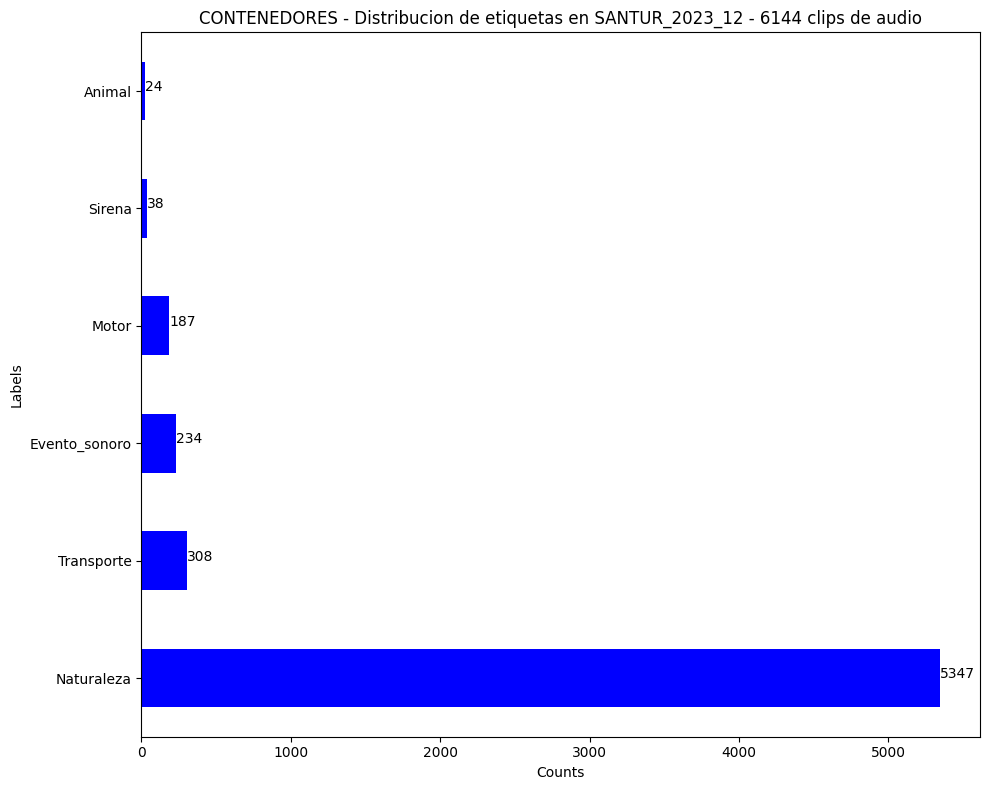

In [28]:
files = os.listdir(PATH)
all_labels = []
total_audio_files = 0

for file in files:
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(PATH, file))
        all_labels.extend(df['label'])
        total_audio_files += len(df)

label_data = pd.Series(all_labels)
# calculate value counts and convert to percentage
# label_counts = label_data.value_counts(normalize=True) * 100
label_counts = label_data.value_counts()

output_path = os.path.join(PATH, "plots")
os.makedirs(output_path, exist_ok=True)

# plot
plt.figure(figsize=(10, 8))
label_counts.plot(kind='barh', color='blue')
plt.title(f'CONTENEDORES - Distribucion de etiquetas en {title} - {total_audio_files} clips de audio')
plt.xlabel('Counts')
plt.ylabel('Labels')

#annotate each bar with percentage
for index, value in enumerate(label_counts):
    plt.text(value, index, f'{value}')

plt.tight_layout()
# plt.show()

plt.savefig(os.path.join(output_path, 'count_distribution.png'))
print(f'Total number of audio files: {total_audio_files}')